In [1]:
!pip install tensorflow

try:
  %tensorflow_version 2.x
except Exception:
  pass

  import tensorflow as tf
  print(tf.__version__)

Colab only includes TensorFlow 2.x; %tensorflow_version has no effect.


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.layers import Dense, Input, GlobalMaxPooling1D
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Embedding
from tensorflow.keras.models import Model

In [3]:
# Pega o csv do site lazyprogrammer
!wget https://lazyprogrammer.me/course_files/spam.csv

--2026-07-18 22:50:34--  https://lazyprogrammer.me/course_files/spam.csv
Resolving lazyprogrammer.me (lazyprogrammer.me)... 104.21.23.210, 172.67.213.166, 2606:4700:3036::ac43:d5a6, ...
Connecting to lazyprogrammer.me (lazyprogrammer.me)|104.21.23.210|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 503663 (492K) [text/csv]
Saving to: ‘spam.csv’

spam.csv            100%[===================>] 491.86K  2.24MB/s    in 0.2s    

2026-07-18 22:50:35 (2.24 MB/s) - ‘spam.csv’ saved [503663/503663]



In [4]:
# Passa o csv para um dataframe do pandas
df = pd.read_csv('spam.csv', encoding='ISO-8859-1')

In [5]:
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [6]:
# Tira as colunas desnecessárias
df = df.drop(["Unnamed: 2", "Unnamed: 3", "Unnamed: 4"], axis=1)

In [7]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [8]:
# Renomeia as colunas
df.columns = ['labels', 'data']

In [9]:
df.head()

,labels,data
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [11]:
# Cria rotulos binarios para passar como entrada para rede neural
df['b_labels'] = df['labels'].map({'ham': 0, 'spam': 1})
Y = df['b_labels'].values

In [12]:
# Separa os dados para treino e teste usando train_test_split
df_train, df_test, Ytrain, Ytest = train_test_split(df['data'], Y, test_size=0.33)

In [14]:
# Converte as frases para sequencias de numeros inteiros usando o tokenizer
MAX_VOCAB_SIZE = 20000
# Ajusta o texto
tokenizer = Tokenizer(num_words=MAX_VOCAB_SIZE)
tokenizer.fit_on_texts(df_train)
# Chama duas testo para sequencias nos conjuntos de treino e teste
sequences_train = tokenizer.texts_to_sequences(df_train)
sequences_test = tokenizer.texts_to_sequences(df_test)

In [16]:
from os import WCOREDUMP
# Pega o mapping do indice de palavras e o tamanho do vocabulario
word2idx = tokenizer.word_index
V = len(word2idx)
# Mostra os tokens unicos encontrados
print('Found %s unique tokens.' % V)

Found 7255 unique tokens.


In [17]:
data_train = pad_sequences(sequences_train)
print('Shape of data train tensor:', data_train.shape)

# Tamanho da sequencia
T = data_train.shape[1]

Shape of data train tensor: (3733, 189)


In [18]:
data_test = pad_sequences(sequences_test, maxlen=T)
print('Shape of data test tensor:', data_test.shape)

Shape of data test tensor: (1839, 189)


In [19]:
# Cria o modelo
D = 20

i = Input(shape=(T,))
x = Embedding(V + 1, D)(i)
x = Conv1D(32, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(64, 3, activation='relu')(x)
x = MaxPooling1D(3)(x)
x = Conv1D(128, 3, activation='relu')(x)
x = GlobalMaxPooling1D()(x)
x = Dense(1, activation='sigmoid')(x)

model = Model(i, x)

In [20]:
# Compila o modelo e treina
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy'])

print('Training model...')
r = model.fit(
    data_train,
    Ytrain,
    epochs=5,
    validation_data=(data_test, Ytest)
)

Training model...
Epoch 1/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.8588 - loss: 0.3825 - val_accuracy: 0.8668 - val_loss: 0.2510
Epoch 2/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9432 - loss: 0.1279 - val_accuracy: 0.9772 - val_loss: 0.0675
Epoch 3/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9933 - loss: 0.0231 - val_accuracy: 0.9788 - val_loss: 0.0683
Epoch 4/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 2s 19ms/step - accuracy: 0.9971 - loss: 0.0091 - val_accuracy: 0.9853 - val_loss: 0.0593
Epoch 5/5
117/117 ━━━━━━━━━━━━━━━━━━━━ 4s 32ms/step - accuracy: 0.9995 - loss: 0.0039 - val_accuracy: 0.9864 - val_loss: 0.0620


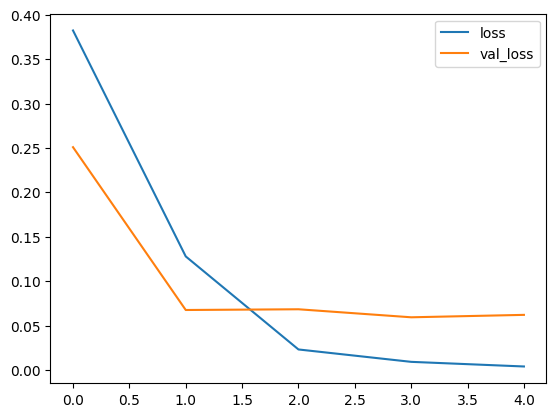

In [21]:
# Plota um grafico com a perda por iteracao
import matplotlib.pyplot as plt
plt.plot(r.history['loss'], label='loss')
plt.plot(r.history['val_loss'], label='val_loss')
plt.legend()

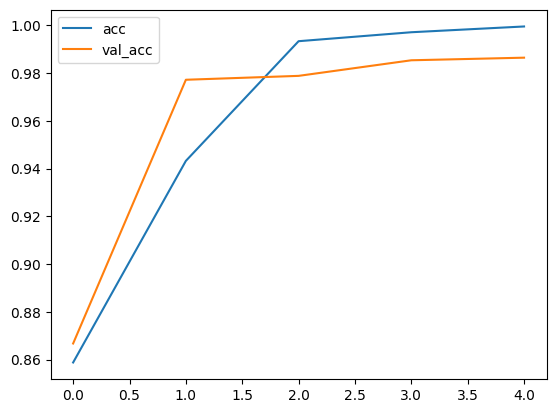

In [22]:
# plota um grafico com a acuracia por iteracao
plt.plot(r.history['accuracy'], label='acc')
plt.plot(r.history['val_accuracy'], label='val_acc')
plt.legend()